# Simple LSTM Dataset Pipeline

This notebook does one thing: turn daily patient feature rows into LSTM-ready arrays.

The idea is simple:

- Use **7 previous days** as input.
- Predict the **next day**.

## 1. Setup

Change `DATA_PATH` if you want to use a different CSV. All generated `.npy` files go into `lstm_npy_outputs/`.

The last cell deletes that folder by default. Set `DELETE_OUTPUTS_AFTER_RUN = False` if you want to keep the files after running the notebook.

In [1]:
import re
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATA_PATH = Path("features_dataset.csv")  # Change to Path("features_dataset.csv") if needed.
OUTPUT_DIR = Path("lstm_npy_outputs")
DELETE_OUTPUTS_AFTER_RUN = True

INPUT_DAYS = 7
RANDOM_STATE = 42

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# Start clean each time this notebook runs.
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Pick Features

These are the exact features used for both input and prediction target.

In [2]:
FEATURE_COLUMNS = [
    "walk_duration",
    "walking_speed",
    "cadence",
    "step_count",
    "left_turn_duration",
    "left_turn_step_count",
    "left_turn_mean_angular_velocity",
    "left_turn_peak_angular_velocity",
    "right_turn_duration",
    "right_turn_step_count",
    "right_turn_mean_angular_velocity",
    "right_turn_peak_angular_velocity",
    "sit_to_stand_flexion_peak",
    "sit_to_stand_extension_peak",
    "stand_to_sit_flexion_peak",
    "stand_to_sit_extension_peak",
]

ID_COLUMNS = ["patient_id", "date"]
KEEP_COLUMNS = ID_COLUMNS + FEATURE_COLUMNS
NUM_FEATURES = len(FEATURE_COLUMNS)

print(f"Using {NUM_FEATURES} features")

Using 16 features


## 3. Load and Preview

Load the CSV and look at the first few rows before changing anything.

In [3]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Raw shape: {raw_df.shape}")
raw_df.head()

Loaded: features_dataset.csv
Raw shape: (35, 81)


,patient_id,date,walk_duration,step_count,cadence,walking_speed,mean_step_time,step_time_std,step_time_cv,step_regularity,...,stand_to_sit_flexion_peak,stand_to_sit_extension_peak,stand_to_sit_peak_gyro,stand_to_sit_acc_rms,stand_to_sit_jerk_mean,stand_to_sit_jerk_std,stand_to_sit_peak_count,stand_to_sit_entropy,sitstand_standsit_xcorr_symmetry_score,sitstand_standsit_xcorr_peak_correlation
0,patient_103,2026-03-03,16.9,15.80,67.714,0.592,0.887,0.028,0.031,0.046,...,0.974,-1.014,1.106,0.588,14.477,41.194,10.0,0.561,0.53,0.53
1,patient_103,2026-03-08,12.9,18.95,87.462,0.775,0.686,0.018,0.027,-0.120,...,1.110,-1.172,1.490,0.912,20.114,33.363,3.0,0.513,0.42,0.42
2,patient_103,2026-03-16,10.9,15.95,87.000,0.917,0.691,0.034,0.049,0.292,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,patient_103,2026-03-26,20.9,12.45,67.909,0.478,0.884,0.026,0.030,0.415,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,patient_103,2026-03-30,13.9,17.80,76.286,0.719,0.787,0.020,0.025,-0.177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Check Columns

If the CSV is missing required columns, stop here and show exactly what is missing.

In [4]:
print("Columns in file:")
for column in raw_df.columns:
    print("-", column)

missing_columns = [column for column in KEEP_COLUMNS if column not in raw_df.columns]

if missing_columns:
    print("\nMissing required columns:")
    for column in missing_columns:
        print("-", column)
    raise SystemExit("Fix the missing columns before continuing.")

print("\nAll required columns are present.")

Columns in file:
- patient_id
- date
- walk_duration
- step_count
- cadence
- walking_speed
- mean_step_time
- step_time_std
- step_time_cv
- step_regularity
- stride_regularity
- walk_acc_mag_mean
- walk_acc_mag_std
- walk_acc_mag_rms
- walk_gyro_mag_std
- walk_dominant_frequency
- walk_spectral_entropy
- walk_jerk_mean
- walk_jerk_std
- approximate_entropy
- sample_entropy
- symbolic_entropy
- permutation_entropy
- rosenstein_lyapunov_exponent
- wolf_lyapunov_exponent
- rqa_REC
- rqa_DET
- rqa_LAM
- rqa_MeanL
- rqa_MaxL
- rqa_EntrL
- rqa_EntrV
- rqa_EntrW
- left_turn_duration
- left_turn_mean_angular_velocity
- left_turn_peak_angular_velocity
- left_turn_ang_vel_std
- left_turn_step_count
- left_turn_pause_time
- left_turn_jerk_std
- left_turn_entropy
- right_turn_duration
- right_turn_mean_angular_velocity
- right_turn_peak_angular_velocity
- right_turn_ang_vel_std
- right_turn_step_count
- right_turn_pause_time
- right_turn_jerk_std
- right_turn_entropy
- turn_duration_difference
-

## 5. Clean Rows

Keep only useful rows and columns:

- Remove missing `patient_id`.
- Remove missing `date`.
- Parse the real date.
- Keep only the selected columns.

In [5]:
def parse_date(value):
    if pd.isna(value):
        return pd.NaT
    text = str(value)
    match = re.search(r"\d{4}-\d{2}-\d{2}", text)
    if match:
        return pd.to_datetime(match.group(0), errors="coerce")
    return pd.to_datetime(text, errors="coerce")

clean_df = raw_df.copy()
clean_df = clean_df[clean_df["patient_id"].notna()].copy()
clean_df = clean_df[clean_df["date"].notna()].copy()
clean_df = clean_df[clean_df["patient_id"] != "_screenshots"].copy()
clean_df["date"] = clean_df["date"].apply(parse_date)
clean_df = clean_df[clean_df["date"].notna()].copy()
clean_df = clean_df[KEEP_COLUMNS].copy()

for column in FEATURE_COLUMNS:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

clean_df = clean_df.sort_values(["patient_id", "date"]).reset_index(drop=True)

print(f"Shape after basic cleaning: {clean_df.shape}")
clean_df.head()

Shape after basic cleaning: (35, 18)


,patient_id,date,walk_duration,walking_speed,cadence,step_count,left_turn_duration,left_turn_step_count,left_turn_mean_angular_velocity,left_turn_peak_angular_velocity,right_turn_duration,right_turn_step_count,right_turn_mean_angular_velocity,right_turn_peak_angular_velocity,sit_to_stand_flexion_peak,sit_to_stand_extension_peak,stand_to_sit_flexion_peak,stand_to_sit_extension_peak
0,patient_103,2026-03-03,16.9,0.592,67.714,15.80,7.607,11.0,0.797,2.023,8.815,11.0,0.747,2.061,1.232,-1.300,0.974,-1.014
1,patient_103,2026-03-08,12.9,0.775,87.462,18.95,5.864,7.0,1.111,2.307,5.214,7.0,1.090,2.176,1.843,-1.944,1.110,-1.172
2,patient_103,2026-03-16,10.9,0.917,87.000,15.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,patient_103,2026-03-26,20.9,0.478,67.909,12.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,patient_103,2026-03-30,13.9,0.719,76.286,17.80,4.821,5.0,1.152,2.189,4.811,5.0,0.975,2.082,NaN,NaN,NaN,NaN


## 6. Fill Missing Feature Values

Missing values are filled within each patient only:

1. Forward fill from earlier days.
2. Backward fill from later days.

This avoids mixing data between patients.

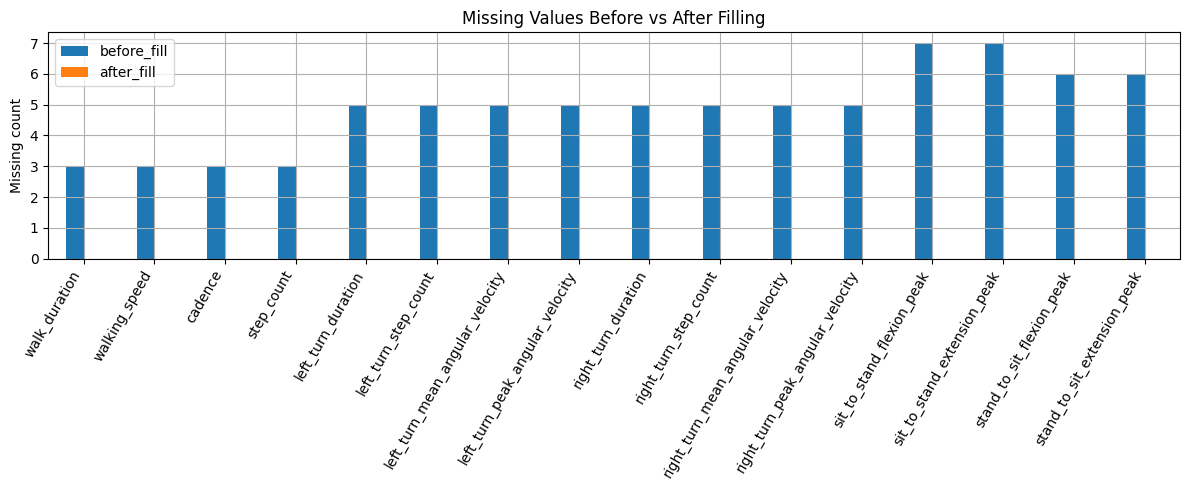

,before_fill,after_fill
walk_duration,3,0
walking_speed,3,0
cadence,3,0
step_count,3,0
left_turn_duration,5,0
left_turn_step_count,5,0
left_turn_mean_angular_velocity,5,0
left_turn_peak_angular_velocity,5,0
right_turn_duration,5,0
right_turn_step_count,5,0


In [6]:
missing_before = clean_df[FEATURE_COLUMNS].isna().sum()

filled_df = clean_df.copy()
filled_df[FEATURE_COLUMNS] = (
    filled_df
    .groupby("patient_id", group_keys=False)[FEATURE_COLUMNS]
    .apply(lambda patient_rows: patient_rows.ffill().bfill())
)

missing_after = filled_df[FEATURE_COLUMNS].isna().sum()

missing_table = pd.DataFrame({
    "before_fill": missing_before,
    "after_fill": missing_after,
})

missing_table.plot(kind="bar", title="Missing Values Before vs After Filling")
plt.ylabel("Missing count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

missing_table

## 7. Quick Patient Plot

Plot a few features for one patient so you can visually check the cleaned data.

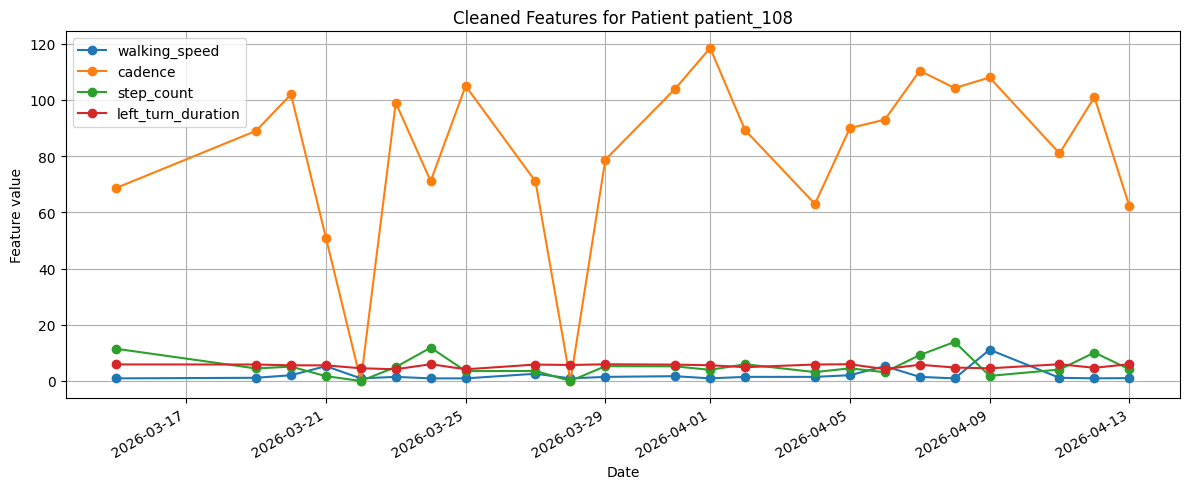

In [7]:
def pick_patient(df, min_rows=2):
    counts = df.groupby("patient_id").size().sort_values(ascending=False)
    counts = counts[counts >= min_rows]
    if counts.empty:
        return None
    return counts.index[0]

sample_patient = pick_patient(filled_df)
plot_features = ["walking_speed", "cadence", "step_count", "left_turn_duration"]

if sample_patient is None:
    print("No patient available to plot.")
else:
    patient_df = filled_df[filled_df["patient_id"] == sample_patient].sort_values("date")
    patient_df.plot(x="date", y=plot_features, marker="o")
    plt.title(f"Cleaned Features for Patient {sample_patient}")
    plt.xlabel("Date")
    plt.ylabel("Feature value")
    plt.tight_layout()
    plt.show()

## 8. Keep Only Usable Patients

A patient needs at least 8 rows:

- 7 rows for input.
- 1 row for the next-day target.

In [8]:
# Drop rows that still have no feature values at all.
usable_df = filled_df[~filled_df[FEATURE_COLUMNS].isna().all(axis=1)].copy()

row_counts = usable_df.groupby("patient_id").size()
usable_patient_ids = row_counts[row_counts >= INPUT_DAYS + 1].index
usable_df = usable_df[usable_df["patient_id"].isin(usable_patient_ids)].copy()
usable_df = usable_df.sort_values(["patient_id", "date"]).reset_index(drop=True)

print(f"Total patients in raw data: {raw_df['patient_id'].nunique(dropna=True)}")
print(f"Usable patients: {usable_df['patient_id'].nunique()}")
print(f"Rows after cleaning: {len(usable_df)}")

Total patients in raw data: 3
Usable patients: 1
Rows after cleaning: 23


## 9. Normalize Per Patient

Normalize each patient separately using:

`z = (x - mean) / std`

If `std` is 0 or missing, use 1.0 instead.

In [9]:
normalized_parts = []

for patient_id, patient_df in usable_df.groupby("patient_id", sort=False):
    patient_norm = patient_df.copy()
    means = patient_norm[FEATURE_COLUMNS].mean()
    stds = patient_norm[FEATURE_COLUMNS].std().replace(0, 1.0).fillna(1.0)
    patient_norm[FEATURE_COLUMNS] = (patient_norm[FEATURE_COLUMNS] - means) / stds
    normalized_parts.append(patient_norm)

if normalized_parts:
    normalized_df = pd.concat(normalized_parts, ignore_index=True)
else:
    normalized_df = usable_df.copy()

normalized_df = normalized_df.sort_values(["patient_id", "date"]).reset_index(drop=True)

print(f"Normalized shape: {normalized_df.shape}")
normalized_df[FEATURE_COLUMNS].describe().T[["mean", "std", "min", "max"]]

Normalized shape: (23, 18)


,mean,std,min,max
walk_duration,-7.433667e-16,1.0,-2.016402,1.040649
walking_speed,-1.134358e-16,1.0,-0.504706,3.899985
cadence,-2.413528e-16,1.0,-2.604249,1.211406
step_count,-2.172175e-16,1.0,-1.430752,2.354200
left_turn_duration,1.641199e-15,1.0,-1.778672,0.923064
left_turn_step_count,4.247810e-16,1.0,-1.899021,2.071660
left_turn_mean_angular_velocity,-9.654113e-17,1.0,-2.404755,1.843604
left_turn_peak_angular_velocity,-5.309762e-16,1.0,-1.646931,1.917054
right_turn_duration,1.979093e-16,1.0,-2.417070,1.048660
right_turn_step_count,-1.641199e-16,1.0,-1.955368,1.792421


## 10. Plot Normalized Data

This plot should look centered around zero because the values are now patient-wise z-scores.

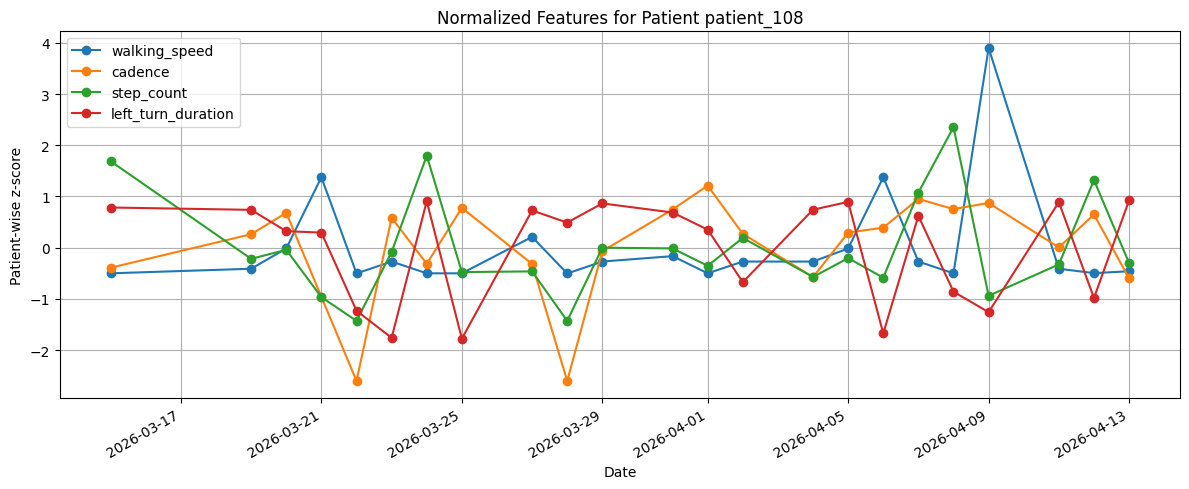

In [10]:
sample_patient = pick_patient(normalized_df, min_rows=INPUT_DAYS + 1)
plot_features = ["walking_speed", "cadence", "step_count", "left_turn_duration"]

if sample_patient is None:
    print("No usable patient available to plot.")
else:
    patient_df = normalized_df[normalized_df["patient_id"] == sample_patient].sort_values("date")
    patient_df.plot(x="date", y=plot_features, marker="o")
    plt.title(f"Normalized Features for Patient {sample_patient}")
    plt.xlabel("Date")
    plt.ylabel("Patient-wise z-score")
    plt.tight_layout()
    plt.show()

## 11. Build 7-Day Windows

For each patient:

- `X` is 7 days of features.
- `y` is the next day.

Example: days 1-7 predict day 8.

In [11]:
X_list = []
y_list = []
window_patient_ids = []

for patient_id, patient_df in normalized_df.groupby("patient_id", sort=False):
    patient_df = patient_df.sort_values("date").reset_index(drop=True)
    values = patient_df[FEATURE_COLUMNS].to_numpy(dtype=np.float32)

    for start in range(0, len(values) - INPUT_DAYS):
        end = start + INPUT_DAYS
        X_list.append(values[start:end])
        y_list.append(values[end])
        window_patient_ids.append(patient_id)

if X_list:
    X_all = np.stack(X_list).astype(np.float32)
    y_all = np.stack(y_list).astype(np.float32)
else:
    X_all = np.empty((0, INPUT_DAYS, NUM_FEATURES), dtype=np.float32)
    y_all = np.empty((0, NUM_FEATURES), dtype=np.float32)

window_patient_ids = np.array(window_patient_ids)

print(f"X_all shape: {X_all.shape}")
print(f"y_all shape: {y_all.shape}")

X_all shape: (16, 7, 16)
y_all shape: (16, 16)


## 12. Split by Patient

Split by patient, not by rows. This keeps one patient's windows from appearing in multiple splits.

In [12]:
def split_patients(patient_ids):
    patient_ids = np.array(sorted(pd.Index(patient_ids).dropna().unique()))
    n_patients = len(patient_ids)

    if n_patients == 0:
        return np.array([]), np.array([]), np.array([])
    if n_patients == 1:
        return patient_ids, np.array([]), np.array([])
    if n_patients == 2:
        train_ids, test_ids = train_test_split(patient_ids, test_size=1, random_state=RANDOM_STATE)
        return np.array(train_ids), np.array([]), np.array(test_ids)

    test_count = max(1, round(n_patients * 0.20))
    train_val_ids, test_ids = train_test_split(patient_ids, test_size=test_count, random_state=RANDOM_STATE)

    val_count = max(1, round(len(train_val_ids) * 0.20))
    if val_count >= len(train_val_ids):
        val_count = 1

    train_ids, val_ids = train_test_split(train_val_ids, test_size=val_count, random_state=RANDOM_STATE)
    return np.array(train_ids), np.array(val_ids), np.array(test_ids)

train_ids, val_ids, test_ids = split_patients(window_patient_ids)

train_mask = np.isin(window_patient_ids, train_ids)
val_mask = np.isin(window_patient_ids, val_ids)
test_mask = np.isin(window_patient_ids, test_ids)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

print(f"Train patients: {len(train_ids)}")
print(f"Validation patients: {len(val_ids)}")
print(f"Test patients: {len(test_ids)}")
print()
print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")

Train patients: 1
Validation patients: 0
Test patients: 0

X_train: (16, 7, 16)  y_train: (16, 16)
X_val:   (0, 7, 16)  y_val:   (0, 16)
X_test:  (0, 7, 16)  y_test:  (0, 16)


## 13. Save Files in One Folder

Save the cleaned CSV and `.npy` arrays into `lstm_npy_outputs/`. This keeps generated files away from the rest of the repo.

In [13]:
normalized_df.to_csv(OUTPUT_DIR / "cleaned_lstm_features.csv", index=False)

np.save(OUTPUT_DIR / "X_train.npy", X_train)
np.save(OUTPUT_DIR / "y_train.npy", y_train)
np.save(OUTPUT_DIR / "X_val.npy", X_val)
np.save(OUTPUT_DIR / "y_val.npy", y_val)
np.save(OUTPUT_DIR / "X_test.npy", X_test)
np.save(OUTPUT_DIR / "y_test.npy", y_test)

print(f"Saved files in: {OUTPUT_DIR.resolve()}")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f"- {path.name}")

Saved files in: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/lstm_npy_outputs
- X_test.npy
- X_train.npy
- X_val.npy
- cleaned_lstm_features.csv
- y_test.npy
- y_train.npy
- y_val.npy


## 14. Baseline Check

Simple baseline: predict tomorrow is the same as the last input day.

This gives a basic MAE score before trying an LSTM.

In [14]:
if len(X_test) == 0:
    print("No test samples available for baseline MAE.")
else:
    baseline_pred = X_test[:, -1, :]
    errors = np.abs(baseline_pred - y_test)

    print(f"Overall baseline MAE: {errors.mean():.4f}")

    baseline_table = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "baseline_mae": errors.mean(axis=0),
    })
    baseline_table

No test samples available for baseline MAE.


## 15. LSTM

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 809ms/step - loss: 0.7524 - mae: 0.7524
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7437 - mae: 0.7437
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7353 - mae: 0.7353
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7270 - mae: 0.7270
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7193 - mae: 0.7193
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7118 - mae: 0.7118
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7046 - mae: 0.7046
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.6972 - mae: 0.6972
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6899 - mae: 0.6899
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6827 - mae: 0.6827
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6758 - mae: 0.6758
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6692 - mae: 0.6692
Epoch 13/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.

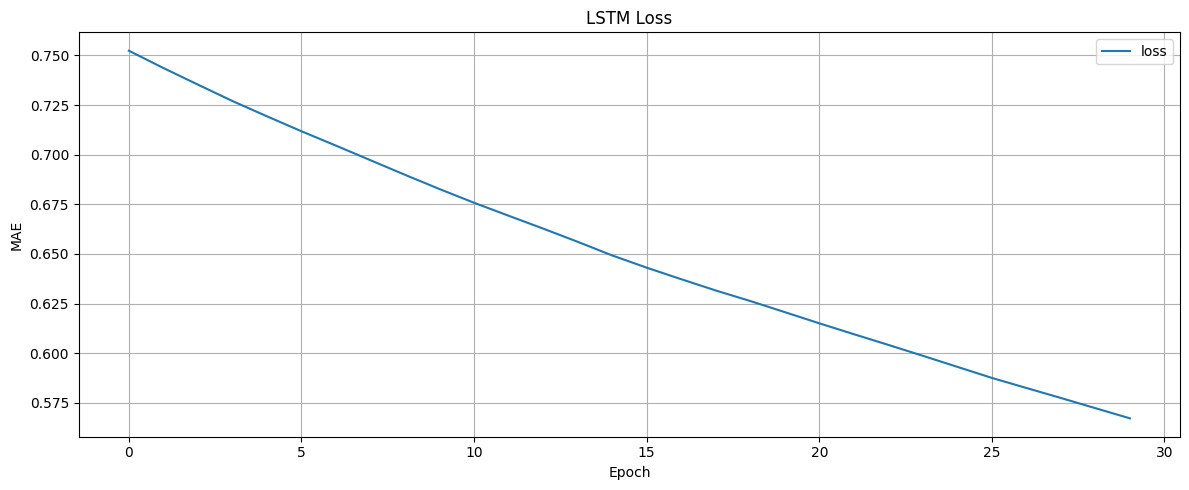

No test samples available for LSTM evaluation.


In [15]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    if len(X_train) == 0:
        print("No training samples available.")
    else:
        tf.random.set_seed(RANDOM_STATE)

        model = keras.Sequential([
            layers.Input(shape=(INPUT_DAYS, NUM_FEATURES)),
            layers.LSTM(64),
            layers.Dense(NUM_FEATURES),
        ])

        model.compile(optimizer="adam", loss="mae", metrics=["mae"])

        fit_kwargs = {
            "x": X_train,
            "y": y_train,
            "epochs": 30,
            "batch_size": min(32, max(1, len(X_train))),
            "verbose": 1,
        }

        if len(X_val) > 0:
            fit_kwargs["validation_data"] = (X_val, y_val)

        history = model.fit(**fit_kwargs)

        pd.DataFrame(history.history)[[column for column in ["loss", "val_loss"] if column in history.history]].plot()
        plt.title("LSTM Loss")
        plt.xlabel("Epoch")
        plt.ylabel("MAE")
        plt.tight_layout()
        plt.show()

        if len(X_test) > 0:
            results = model.evaluate(X_test, y_test, verbose=0, return_dict=True)
            print(f"LSTM test MAE: {results['mae']:.4f}")
        else:
            print("No test samples available for LSTM evaluation.")

except ImportError:
    print("TensorFlow is not installed, so the optional LSTM cell was skipped.")

## 16. Delete Generated Output Folder

This keeps the repository clean. By default, the generated `.npy` files are deleted after the notebook runs.

Set `DELETE_OUTPUTS_AFTER_RUN = False` in the first code cell if you want to keep them.

In [16]:
if DELETE_OUTPUTS_AFTER_RUN:
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)
    print(f"Deleted generated output folder: {OUTPUT_DIR}")
else:
    print(f"Kept generated output folder: {OUTPUT_DIR.resolve()}")

Deleted generated output folder: lstm_npy_outputs
